In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("final_cleaned_dataset.csv")
print(df.head())

   area_sqft  bedrooms  bathrooms  floors  property_age  renovation_status  \
0       1710         3        2.5       2            23                  0   
1       1262         3        2.0       1            50                  0   
2       1786         3        2.5       2            25                  1   
3       1717         3        1.0       2           111                  1   
4       2198         4        2.5       2            26                  0   

   lot_size  distance_city_km  neighborhood_score  crime_rate_index  ...  \
0      8450              4.72                 6.9               2.3  ...   
1      9600              4.66                 5.4               4.7  ...   
2     11250              6.27                 6.9               2.8  ...   
3      9550              6.30                 6.6               2.9  ...   
4     14260              6.90                 7.7               2.1  ...   

   green_space_index  flood_risk_index  noise_pollution_level  SalePrice  

In [86]:
print("LINEAR _REGRESSION")

LINEAR _REGRESSION


Train R2: 0.9914544365662978
MAE: 21197.04680371217
RMSE: 30690.65553741355


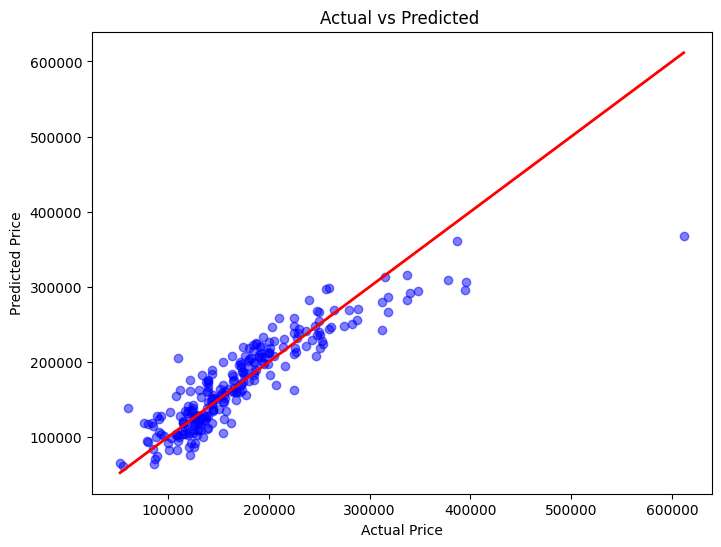

In [87]:

X = df.drop('SalePrice', axis=1)
y = df['SalePrice'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)


y_pred = lr_raw.predict(X_test)

# Evaluation
print(f"Train R2: {r2_score(y_train, train_pred):}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted ")
plt.show()

In [88]:
train_pred = lr_raw.predict(X_train)
print("Model Performance (No Log Transform) ---")
print(f"Train R2: {r2_score(y_train, train_pred):}")
print(f"Test R2:  {r2_score(y_test, y_pred):}")

Model Performance (No Log Transform) ---
Train R2: 0.8354707634772782
Test R2:  0.8065400503162407


In [89]:
my_house = {
    'area_sqft': 1800,
    'bedrooms': 3,
    'bathrooms': 2.5,
    'floors': 2,
    'property_age': 10,
    'renovation_status': 1,
    'lot_size': 9000,
    'distance_city_km': 5.0,
    'neighborhood_score': 8.5,
    'crime_rate_index': 1.2,
    'green_space_index': 7.0,
    'flood_risk_index': 1.0,
    'noise_pollution_level': 3.0,
    'Fireplaces': 1,
    'school_rating': 8,
    'hospital_proximity_km': 2.5,
    'shopping_center_proximity_km': 1.2,
    'public_transport_score': 7.5,
    'parking_availability': 1,
    'construction_quality': 4,
    'energy_efficiency_score': 8,
    'water_supply_score': 9,
    'electricity_supply_score': 9,
    'internet_availability_score': 8,
    'property_type_1Fam': 1,
    'property_type_2fmCon': 0,
    'property_type_Duplex': 0,
    'property_type_Twnhs': 0,
    'property_type_TwnhsE': 0
}


In [90]:
def predict_house_price_no_log(input_data):
    input_df = pd.DataFrame([input_data])
    
    input_df = input_df[X.columns]
    
    prediction = lr_raw.predict(input_df)[0]
    
    return prediction

estimated_value = predict_house_price_no_log(my_house)

print("--- Prediction Result (No Log) ---")
print(f"Predicted Market Value: ₹{estimated_value:,.2f}")

--- Prediction Result (No Log) ---
Predicted Market Value: ₹168,378.40


In [91]:
print("LINEAR REGRESSION WITH LOG TRANSFORMATION")

LINEAR REGRESSION WITH LOG TRANSFORMATION


R2 Score: 0.8532693662545658
Actual MAE: 18622.867749131405
MSE: 26728.280863336524


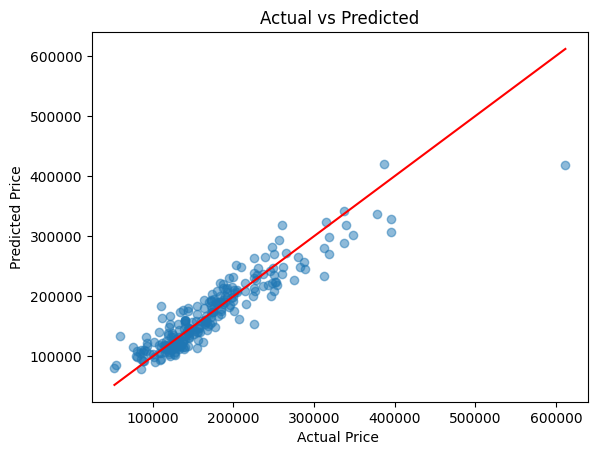

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error


X = df.drop('SalePrice', axis=1)

# log transformation
y_log = np.log1p(df['SalePrice']) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train, y_train_log)


y_pred_log = lr.predict(X_test)

# CONVERT 
y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)
y_pred_original = np.expm1(y_pred_log)

#  Evaluation
print(f"R2 Score: {r2_score(y_test_original, y_pred_original):}")
print(f"Actual MAE: {mean_absolute_error(y_test_original, y_pred_original):}")
print("MSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))

# linear regression
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], color='red')
plt.xlabel("Actual Price ")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [93]:
train_pred_log = lr.predict(X_train)
train_pred = np.expm1(train_pred_log)

train_r2 = r2_score(y_train_original, train_pred)
test_r2 = r2_score(y_test_original, y_pred_original)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.8686121165737715
Test R2: 0.8532693662545658


In [94]:

def predict_house_price(input_data):
    
    input_df = pd.DataFrame([input_data])
    
    
    input_df = input_df[X.columns]
    
  
    log_prediction = lr.predict(input_df)
    actual_price = np.expm1(log_prediction)[0]
    
    return actual_price



estimated_value = predict_house_price(my_house)

print(" Prediction Result ")
print(f"Predicted Market Value: {estimated_value:,.2f}")

 Prediction Result 
Predicted Market Value: 166,651.41


In [95]:
print("RANDOM FOREST REGRESSION")

RANDOM FOREST REGRESSION


 Random Forest Performance
Train R2: 0.9753759008561677
Test R2:  0.8005363274696408
MAE:      19908.41568548387
RMSE:     31163.23503145806


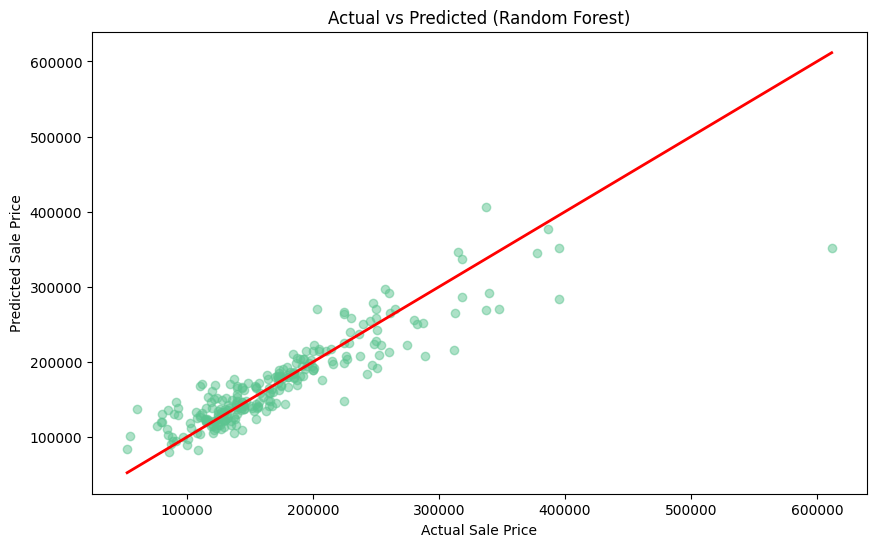

In [98]:
from sklearn.ensemble import RandomForestRegressor


X = df.drop('SalePrice', axis=1)
y = df['SalePrice'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)


print(" Random Forest Performance")
print(f"Train R2: {r2_score(y_train, train_pred):}")
print(f"Test R2:  {r2_score(y_test, test_pred):}")
print(f"MAE:      {mean_absolute_error(y_test, test_pred):}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, test_pred)):}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_pred, alpha=0.5, color='#5cc490')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()



In [97]:
def predict_house_price_rf(input_data):

    input_df = pd.DataFrame([input_data])
    
    input_df = input_df[X.columns]
    
    prediction = rf.predict(input_df)[0]
    
    return prediction


estimated_value = predict_house_price_rf(my_house)

print("--- Random Forest Prediction Result ---")
print(f"Estimated Market Value: {estimated_value:,}")

--- Random Forest Prediction Result ---
Estimated Market Value: 177,731.505


In [83]:
print("SUPPORT VECTOR REGRESSION")

SUPPORT VECTOR REGRESSION


In [79]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. SVR REQUIRES SCALING
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scale Features
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale Target 
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()


svr = SVR(kernel='rbf', C=100000, epsilon=0.1) 
svr.fit(X_train_scaled, y_train_scaled)


train_pred_scaled = svr.predict(X_train_scaled)
test_pred_scaled = svr.predict(X_test_scaled)


train_pred = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()
test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()


print("--- SVR Performance ---")
print(f"Train R2: {r2_score(y_train, train_pred):.4f}")
print(f"Test R2:  {r2_score(y_test, test_pred):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, test_pred):,.2f}")

--- SVR Performance ---
Train R2: 0.9915
Test R2:  0.7739
MAE:      24,025.96


In [81]:
def predict_house_price_svr(input_data):
    
    input_df = pd.DataFrame([input_data])
    

    input_df = input_df[X.columns]
    
    input_scaled = scaler_X.transform(input_df)
    
    prediction_scaled = svr.predict(input_scaled)
    
    actual_price = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]
    
    return actual_price

svr_estimated_value = predict_house_price_svr(my_house)

print(" SVR Prediction Result ")
print(f"Estimated Market Value: ₹{svr_estimated_value:,.2f}")

 SVR Prediction Result 
Estimated Market Value: ₹192,883.65
